# Dependent and independent t-tests
#####    Practical assignment 3

This practical assignment need to be handed in on Brightspace before the deadline, 16:00 08/05/2023. Make sure that every cell is executed/compiled and renamed to

**Assignment2_Surname1_Surname2.ipynb**

before submitting. For questions contact your TA during the workgroup, or via mail. Depending on whether all questions are sufficiently answered and if enough effort has been put into the assignment, you wil get good (all questions answered and all topics underestood well), sufficient (enough effort has been put but need to learn more and underestand better) or fail (not enough effort has been put into this assignment).

**Name 1:** Angelina Podolako - s1125886

**Name 2:** Feliks Lysiuk - s1125187

### Dataset

Retirement homes are multi-residence housing facilities intended for the elderly, for a temporary or definitive stay. A problem for these elderly people is feeling lonely, and the need for interaction. This is where AI can help. Robot pets (i.e. a robot on the inside, stuffed animal on the outside) that react on touch, voice, and act on itself, can combat this loneliness (pets usually aren't allowed inside retirement homes).

In today's workgroup you will analyse data from a study interested in investigating the effectiveness of robot pets in combatting loneliness. In this study, the loneliness of elderly people was measured with a questionairre. Both at the start of the study (pre-test), and after spending 3 months with their robot pet (post-test). These questions were summarized into two loneliness scores for each individual (one pre and one post-test score). Elderly were randomly divided into two groups, one group who received a robot dog and another who received a robot cat.

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats

sns.set_style("whitegrid")

In [3]:
from google.colab import files
uploaded = files.upload()

Saving Loneliness.csv to Loneliness.csv


In [4]:
lon_score = pd.read_csv("Loneliness.csv")
lon_score.keys()
print(lon_score)

    Group  Lon_t1  Lon_t2
0       1      80      40
1       1      57      38
2       1      89      47
3       1      70      53
4       1      79      56
..    ...     ...     ...
86      2      72      72
87      2      43      66
88      2      87      41
89      2      70      59
90      2      35      38

[91 rows x 3 columns]


## Part 1

### <span style="color:red"> Question 1.1 </span>
First we are interested whether the robot pets affect loneliness. Describe a hypothesis that tests this. Is this a dependent or independent test (paired or unpaired data)?

Describe hypothesis  
It is probably dependent test, as we are are testing the affect of robot pets on loneliness.


Angelina:
Null hypothesis (H0): There is no difference in the level of loneliness between older people before and after purchasing a pet robot.
loneliness score before spending 3 month with pet robot = loneliness score after spending 3 month with pet robot
->loneliness score difference = 0
----> μ expected​ = 0

Alternative hypothesis (Ha): There is a difference in the level of loneliness between older people before and after purchasing a pet robot.
loneliness score before spending 3 month with pet robot  !=(not equal) loneliness score after spending 3 month with pet robot
->loneliness score difference !=(not equal)  0
----> μ expected​ !=(not equal)  0

Since the same group of elderly people is measured before and after, this is a dependent test. This is a paired test, since the same group of people is tested before and after, and we are interested to find out if each person's performance has changed after receiving the robot.

pet### <span style="color:red"> Question 1.2 </span>
Before doing a statistical test, it is always a good idea to have a look at your data. Choose an appropriate plot to visualize the data.

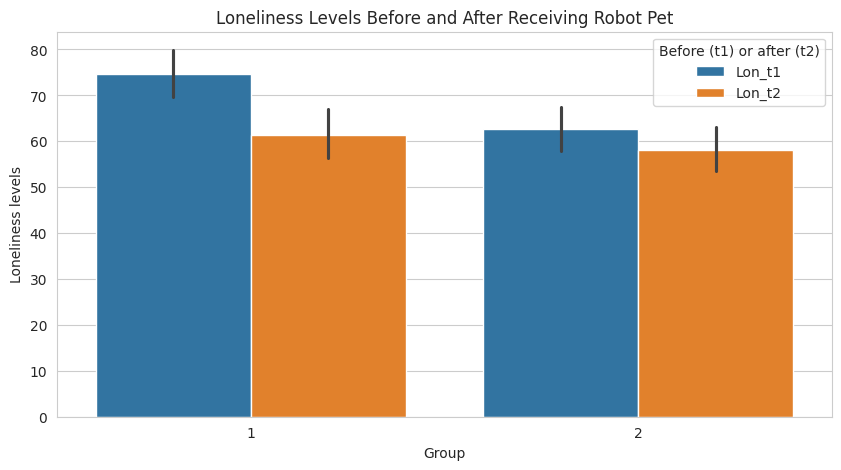

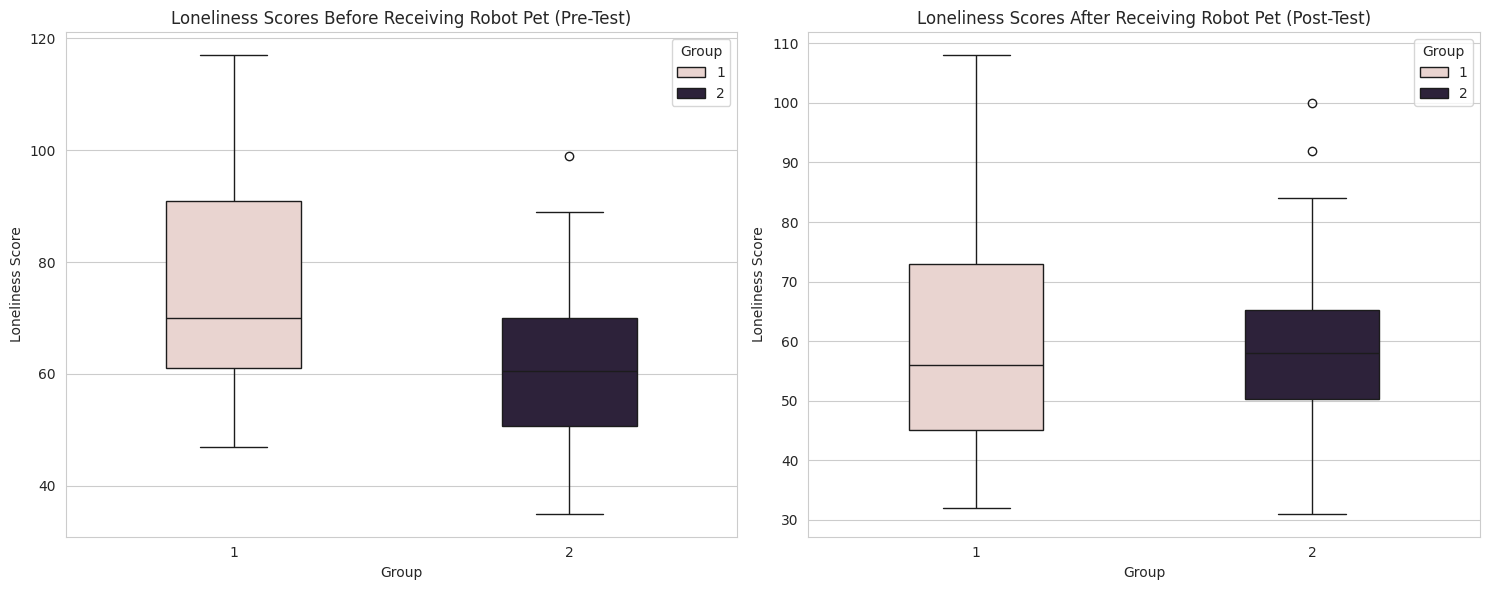

In [5]:
lon_score_melted = pd.melt(lon_score, id_vars=['Group'], var_name = 'Loneliness Level', value_name = 'Lon_t')

plt.figure(figsize=(10, 5))
sns.barplot(x='Group', y='Lon_t', hue='Loneliness Level', data=lon_score_melted)
plt.title('Loneliness Levels Before and After Receiving Robot Pet')
plt.xlabel('Group')
plt.ylabel('Loneliness levels')
plt.legend(title='Before (t1) or after (t2)')
plt.show()

#------------------------------------------------
lon_score = pd.read_csv("Loneliness.csv")

# Create subplots
fig, axs = plt.subplots(1, 2, figsize=(15, 6))

# Plot box plots
sns.boxplot(data=lon_score, x='Group', y='Lon_t1', hue='Group', width=0.4, ax=axs[0])
axs[0].set_title('Loneliness Scores Before Receiving Robot Pet (Pre-Test)')
axs[0].set_xlabel('Group')
axs[0].set_ylabel('Loneliness Score')
axs[0].legend(title='Group')

sns.boxplot(data=lon_score, x='Group', y='Lon_t2', hue='Group', width=0.4, ax=axs[1])
axs[1].set_title('Loneliness Scores After Receiving Robot Pet (Post-Test)')
axs[1].set_xlabel('Group')
axs[1].set_ylabel('Loneliness Score')
axs[1].legend(title='Group')

plt.tight_layout()
plt.show()

Before we can do a statistical test on the data, we will first create a list/array of all the differences of the scores before and after the treatment, such that $$x_{\Delta} = x_{t2}-x_{t1}$$

In [6]:
lon_diff = lon_score['Lon_t2']-lon_score['Lon_t1']
print(lon_diff)

score_differences = lon_diff.tolist()
print(score_differences)

0    -40
1    -19
2    -42
3    -17
4    -23
      ..
86     0
87    23
88   -46
89   -11
90     3
Length: 91, dtype: int64
[-40, -19, -42, -17, -23, -30, -8, 27, -23, -59, -10, -29, -37, -16, 2, 0, -3, -9, 5, -8, -26, -20, -45, 2, -13, -4, -20, -10, -17, -5, -22, 5, 24, -9, -19, 4, -17, -56, -16, -19, 5, -21, -7, -22, 2, 0, 5, 12, -4, -17, -6, -10, -9, 3, -12, 0, 7, -8, -10, -23, -3, 0, 18, 11, 13, 3, -27, -5, -20, -9, 13, -6, -5, -34, -8, -16, -5, -4, 3, -6, -8, 1, -3, 4, 9, 8, 0, 23, -46, -11, 3]


### <span style="color:red"> Question 1.3 </span>

Now that we have these scores we can do a t-test for Paired Data. First, let's calculate the mean,standard deviation, and the number of observations. Create a separate variable for each of these.

In [7]:
lon_diff_mean = lon_diff.mean()
print(lon_diff_mean)

lon_diff_std = lon_diff.std()
print(lon_diff_std)

lon_diff_len = len(lon_diff)
print(lon_diff_len)

-9.274725274725276
16.368714015914584
91


### <span style="color:red"> Question 1.4 </span>
Now that we have these values, we can calculate the standard error (SE) and the T-score. Remember, the T-score is computed the exact same way as the Z-score, where the Z-score relates to the normal distribution and the T-score to a t-distribution with a specific number of degrees of freedom.

First calculate the SE. Remember, the formula for the SE: $$SE_{\bar{x}_{diff}} = \dfrac{s_{diff}}{\sqrt{n_{diff}}}$$



In [8]:
stand_err_mean_difference = lon_diff_std / np.sqrt(lon_diff_len)
print(stand_err_mean_difference)

1.7159074699520795


### <span style="color:red"> Question 1.5 </span>
Second, calculate the T-score. Remember, the formula for the T-score: $$T = \dfrac{\bar{x}_{diff} - \mu_{expected}}{SE_{\bar{x}_{diff}}}$$

In [9]:
mu_expected = 0

t_score = (lon_diff_mean - mu_expected) / stand_err_mean_difference
print(t_score)

-5.405143014491506


### <span style="color:red"> Question 1.6 </span>

Now that we got our T-score, we normally would look it up in a table, or use a function to calculate that for us. Write a function that takes t-score, degree of freedom and a variable specifying one-sided or two-sided test. You can use the stats.t.sf function from the scipy toolbox, to compute the p-value for a given T-score and degrees of freedom.  


In [10]:
def calculate_p_value(T_score, df, two_sided=True):
  if two_sided:
        p_value = 2 * stats.t.sf(np.abs(T_score), df)
  else:
        p_value = stats.t.sf(np.abs(T_score), df)

  return p_value

### <span style="color:red"> Question 1.7 </span>
Finally, use the functions you worte above with the p-value and a signficance level of 0.05 to formulate a conclusion about the hypothesis you specified in question 1.1.

In [25]:
p_value = calculate_p_value(t_score, df=(lon_diff_len - 1), two_sided=True)
print(p_value)

significance_level = 0.05

if p_value < significance_level:
    print("Reject the null hypothesis.")
else:
    print("Fail to reject the null hypothesis.")


5.264906242767012e-07
Reject the null hypothesis.


The difference in the level of loneliness in older people before and after using a pet robot is not accidental and there is enough evidence for this conclusion.
We can reject H0.

## Part 2

Now we have investigated whether the robots have a statistical impact on the loneliness, we're going to look at which robot performed better. The dog or the cat. For this we will look at the difference scores between the pre- and the post-test. Specifically, we will investigate whether the change in loneliness is between the pre-test and the post-test is different between the cats and dogs.



### <span style="color:red"> Question 2.1 </span>

Specify the hypothesis for this test. Is this a dependent or independent test (paired or unpaired data)?

This test is independent, since we compare the change in loneliness score in two different groups (those with a dog or those with a cat), respectively, this test is unpaired, since we have two independent samples.

Null hypothesis (H0): There is no difference in loneliness score between groups of people who received a robot dog or a cat.
H0: µ dog − µ cat=0

Alternative hypothesis (Ha): There is a difference in loneliness score between groups of people who received a robot dog or a cat.
Ha: µ dog − µ cat !=(not equal) 0


Before we go further, lets extract the datapoints that are relevant to us.

In [12]:
dogs = lon_diff[lon_score['Group'] == 1]
cats = lon_diff[lon_score['Group'] == 2]

### <span style="color:red"> Question 2.2 </span>
First, choose an appropriate plot to visualize the data.

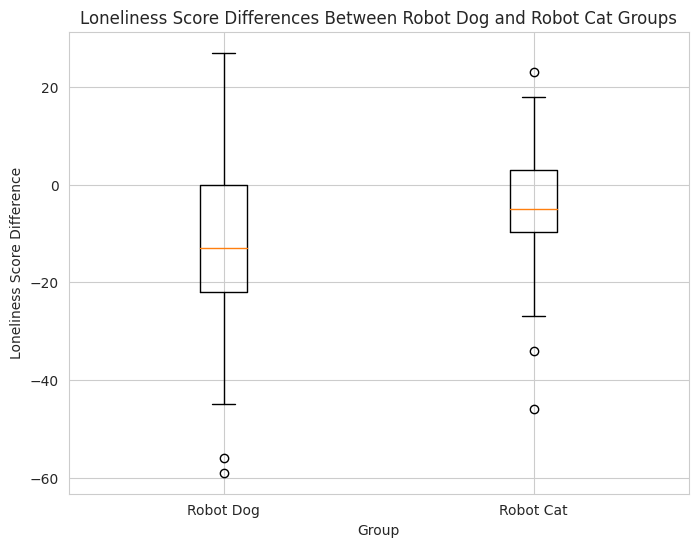

In [13]:
plt.figure(figsize=(8, 6))
plt.boxplot([dogs, cats], labels=['Robot Dog', 'Robot Cat'])
plt.title('Loneliness Score Differences Between Robot Dog and Robot Cat Groups')
plt.xlabel('Group')
plt.ylabel('Loneliness Score Difference')
plt.grid(True)
plt.show()

### <span style="color:red"> Question 2.3 </span>
Now compute the mean, standard deviation and number of observations in each group and store them in separate variables.

In [14]:
dog_mean = dogs.mean()
dog_std = dogs.std()
dog_len = len(dogs)
print("Dogs mean: ", dog_mean, ". Dogs std: ", dog_std, ". Dogs number of observations: ", dog_len)

cat_mean = cats.mean()
cat_std = cats.std()
cat_len = len(cats)
print("Cats mean: ", cat_mean, ". Cats std: ", cat_std, ". Cats number of observations: ", cat_len)

Dogs mean:  -13.306122448979592 . Dogs std:  17.793027756250307 . Dogs number of observations:  49
Cats mean:  -4.571428571428571 . Cats std:  13.244682056865557 . Cats number of observations:  42


### <span style="color:red"> Question 2.4 </span>
Calculate the standard error (SE) of this modelled distribution. Since we take the sample difference of the means, the SE is calculated as follows:

$$SE_{\bar{x}_{group1} - \bar{x}_{group2}} = \sqrt{\dfrac{s^{2}_{group1}}{n_{group1}}+\dfrac{s^{2}_{group2}}{n_{group2}}}$$

In [15]:
stand_err_group_mean_difference = np.sqrt((dog_std**2 / dog_len) + (cat_std**2 / cat_len))
print(stand_err_group_mean_difference)

# for 2.6
SE_dog = dog_std / np.sqrt(dog_len)
SE_cat = cat_std / np.sqrt(cat_len)

print("SE dogs:", SE_dog, "SE cats:", SE_cat)

3.261558327060478
SE dogs: 2.541861108035758 SE cats: 2.0436988105571654


### <span style="color:red"> Question 2.5 </span>

Calculate the t-statistic and the p-value. Keep in mind that we are using t-distribution of the sample difference of two means.

In [24]:
#Calculate the t-statistic (t-score)
mean_difference_groups = dog_mean - cat_mean
mu_expected_groups = 0

t_score_groups = (mean_difference_groups - mu_expected_groups) / stand_err_group_mean_difference
print("T-score: ", t_score_groups)

# Calculate the p-value
df_groups = dog_len + cat_len - 2
print(df_groups)

def calculate_p_value_groups(T_score_groups, df_groups, two_sided_groups=True):
  if two_sided_groups:
        p_value_groups = 2 * stats.t.sf(np.abs(T_score_groups), df_groups)
  else:
        p_value_groups = stats.t.sf(np.abs(T_score_groups), df_groups)

  print("P-value: ", p_value_groups)
  return p_value_groups


#calculate difference p_value = calculate_p_value(t_score, df=(lon_diff_len - 1), two_sided=True)
p_value_groups = calculate_p_value_groups(t_score_groups, df_groups, two_sided_groups=True)
significance_level_groups = 0.05

if p_value_groups < significance_level_groups:
    print("Reject the null hypothesis.")
else:
    print("Fail to reject the null hypothesis.")

T-score:  -2.6780737922363866
89
P-value:  0.00881786466165822
Reject the null hypothesis.


### <span style="color:red"> Question 2.6 </span>
Finally, use the p-value and a signficance level of 0.05 to draw a conclusion about the hypothesis you specified in question 2.1.

The difference in loneliness score in older people using a pet robot cat or dog is not accidental and there is enough evidence for this conclusion.
We can reject H0.

An example of the way statistical tests results are formulated in scientific papers is as follows:
"We observed a significantly higher test score for group1 (M=, SE=) than group2 (M= , SE= ) with t(df)= and p= ."
Formulate the result of your statistical test in this format.

We observed a significantly higher loneliness score difference for the group that received the robot dog (M=dog_mean= -13.31 , SE=SE_dog= 2.54) than the group that received the robot cat (M=cat_mean = -4.57 , SE=SE_cat= 2.04) with t(df= df_groups= 89) = t_score_groups = -2.68, p = p_value_groups = 0.009

## Part 3

In part 1 and 2 you implemented the independent and dependent tests yourself, but of course there are libraries that do this for you. Here we will use those libraries and compare those to our answers in part 1 and 2.

### <span style="color:red"> Question 3.1 </span>

Use `scipy.stats.ttest_rel(...)` ($\href{https://docs.scipy.org/doc/scipy/reference/generated/scipy.stats.ttest_rel.html}{documentation}$) to calculate the p-value of the paired t-test, and check whether this answer is the same as the one we calculated above. (**Note** `scipy.stats` has been imported as `stats`, so you can just use `stats.ttest_rel(...)`)

In [21]:
t_score_rel, p_value_rel = stats.ttest_rel(lon_score['Lon_t1'], lon_score['Lon_t2'])
print(t_score_rel)
print(p_value_rel)

5.4051430144915065
5.264906242767012e-07


### <span style="color:red"> Question 3.2 </span>

Use `scipy.stats.ttest_ind(...)` ($\href{https://docs.scipy.org/doc/scipy/reference/generated/scipy.stats.ttest_ind.html}{documentation}$) to calculate the p-value of the independent t-test, and check whether this answer is the same as the one we calculated above. (**Note** `scipy.stats` has been imported as `stats`, so you can just use `stats.ttest_ind(...)`)

In [23]:
t_score_groups_ind, p_value_ind = stats.ttest_ind(lon_score['Lon_t1'], lon_score['Lon_t2'])
print(t_score_groups_ind)
print(p_value_ind)

3.475054279039987
0.0006399835532628746


There might be slight differences in the t-scores and p-values you computed in questions 1/2 and question 3, due to subtle differences in the computation of the degrees of freedom and the SE.
